## 问题一: 特征图上的归一化坐标能代表原图吗？
**能，完全能代表。**

这是深度学习中非常核心的一个概念：**“相对位置不变性”**。

只要特征图是通过标准的卷积和池化（下采样）操作生成的，**特征图上的归一化坐标 $(x_{norm}, y_{norm})$ 就严格对应原图上相同比例的相对位置。**

---

### 1. 为什么能代表？（数学原理）

假设：
- **原图尺寸**：$W \times H$
- **特征图尺寸**：$w \times h$ （通常是原图缩小了 $S$ 倍，即 $w = W/S, h = H/S$）
- **特征图上的某个点**：索引为 $(i, j)$，其中 $0 \le i < w, 0 \le j < h$

#### 第一步：在特征图上计算归一化坐标
我们通常取每个格子的中心作为锚框中心。
特征图上的归一化坐标 $(x_{fmap}, y_{fmap})$ 计算如下：
$$ x_{fmap} = \frac{i + 0.5}{w} $$
$$ y_{fmap} = \frac{j + 0.5}{h} $$
*(注：加 0.5 是因为取格子中心，而不是左上角)*

此时，$x_{fmap}$ 和 $y_{fmap}$ 的值都在 $0$ 到 $1$ 之间。

#### 第二步：映射回原图
我们要找这个点对应原图的哪个像素位置 $(X_{img}, Y_{img})$。
由于特征图是均匀下采样的，原图对应的坐标就是：
$$ X_{img} = x_{fmap} \times W = \left( \frac{i + 0.5}{w} \right) \times W $$
$$ Y_{img} = y_{fmap} \times H = \left( \frac{j + 0.5}{h} \right) \times H $$

因为 $W = w \times S$ 且 $H = h \times S$（$S$是缩放倍数），代入后：
$$ X_{img} = \frac{i + 0.5}{w} \times (w \times S) = (i + 0.5) \times S $$
$$ Y_{img} = \frac{j + 0.5}{h} \times (h \times S) = (j + 0.5) \times S $$

#### 🎯 结论：
**归一化坐标消去了具体的分辨率差异。**
无论特征图是 $10 \times 10$ 还是 $50 \times 50$，只要归一化坐标是 `0.5`，它在原图上永远代表 **正中间**；只要是 `0.1`，就永远代表 **靠左/靠上 10% 的位置**。

---

### 2. 直观例子

假设原图是 **1000px × 1000px**。
经过网络处理，特征图变成了 **10px × 10px**（缩小了100倍）。

- **特征图上的点**：第 2 行，第 2 列（索引从0开始，即 $i=2, j=2$）。
- **特征图归一化坐标**：
  $$ x = \frac{2 + 0.5}{10} = 0.25 $$
  $$ y = \frac{2 + 0.5}{10} = 0.25 $$
  👉 这表示：该点位于特征图宽高的 **25%** 处。

- **映射回原图**：
  $$ X = 0.25 \times 1000 = 250 $$
  $$ Y = 0.25 \times 1000 = 250 $$
  👉 这表示：该点位于原图宽高的 **25%** 处（即像素坐标 250, 250）。

**你看，`0.25` 这个归一化值，完美地代表了原图和特征图上相同的相对位置。**

---

### 3. 为什么要用归一化坐标？

使用归一化坐标（0~1）有巨大的好处：

1.  **通用性（Scale Invariance）**：
    不管输入图片是 $224 \times 224$ 还是 $1024 \times 1024$，也不管特征图是 $7 \times 7$ 还是 $14 \times 14$，网络输出的锚框坐标格式永远是一样的（0~1的小数）。代码不需要针对每种尺寸重写。

2.  **解耦**：
    网络只需要学习“物体在图像的哪个比例位置”，而不需要关心具体的像素数值。这让模型更容易收敛。

3.  **方便计算 Loss**：
    在训练时，计算预测框和真实框（Ground Truth）的误差时，大家都转换到 0~1 的尺度，数值范围统一，梯度更稳定。

---

### ⚠️ 唯一的前提条件

这种对应关系成立的前提是：**特征图的生成过程必须是空间对齐的（Spatially Aligned）**。
- 标准的卷积（Convolution）和池化（Pooling）都满足这个条件。
- 如果中间使用了某些特殊的操作（如非均匀的下采样、ROI Align之前的裁剪等），可能会破坏这种严格的线性对应关系，但在生成初始锚框（Anchor Generation）阶段，通常都是严格均匀的。

### ✅ 总结

**特征图上的归一化坐标不仅能代表原图，而且是最准确、最通用的代表方式。**
它就像地图上的经纬度（相对坐标），无论地图是画在手机上还是印在墙上（不同分辨率），`北纬 30 度` 永远指向地球上同一个相对位置。

## 问题二：那么锚框在特征图上还是在原图上

简单来说：
1.  **生成的逻辑（位置索引）**：基于**特征图**。
2.  **实际的坐标和可视化**：映射回**原图**。

---

### 🧩 详细拆解：

#### 1. 锚框的“出生地”是特征图
我们在代码中生成锚框时，是遍历**特征图**的每一个像素点（比如 10×10 的网格）。
- 我们说：“在第 `i` 行、第 `j` 列的特征图位置上，生成一个锚框。”
- 此时，这个锚框的**中心坐标**通常是归一化的相对坐标（0~1之间），或者是相对于特征图尺寸的索引。
- **为什么？** 因为特征图代表了网络当前的“视野”，网络只能在这个分辨率下做预测。

#### 2. 锚框的“作用域”是原图
虽然锚框是基于特征图生成的，但它的**最终目的是去框住原图中的物体**。
- 所以，我们必须把特征图上的那个点 `(i, j)`，**映射（ upscale / 反投影）** 回原图的对应位置。
- **计算公式**通常是：
  $$ \text{原图中心} x = \frac{i + 0.5}{\text{特征图宽度}} \times \text{原图宽度} $$
- 锚框的**宽和高**（size）也是相对于**原图**的尺寸定义的（比如原图宽度的 20%）。

#### 3. 结论：它到底在哪？
- **在训练/推理过程中**：网络输出的预测值（偏移量）是相对于**特征图**上的锚框进行的。
- **在可视化/评估结果时**：所有的锚框和预测框都必须转换到**原图**坐标系上，否则你画出来的框会比原图小几十倍，根本看不见。

---

### 💡 为什么要这么设计？

如果直接在原图上生成锚框（比如原图 1000×1000，生成 100 万个锚框）：
1.  **计算量爆炸**：网络要预测 100 万个框的偏移量，显存直接爆掉。
2.  **没必要**：卷积神经网络具有“感受野”特性，特征图上的一个点已经包含了原图一大块区域的信息。在这个抽象层面上做预测更高效。

### ✅ 总结回答你的问题：

> **锚框是在特征图上“定义”的，但在原图上“使用”的。**

当你看到代码里 `display_anchors` 把框画出来时，那些框的坐标**已经是原图的像素坐标了**，所以你会看到它们完美地覆盖在原图上。  

---

## 问题三：通过特征图生成锚框
这段文字出自深度学习目标检测（Object Detection）相关教程，特别是关于**锚框（Anchor Boxes）**生成机制的部分。它试图解释如何在特征图（feature map）上均匀采样锚框中心，并将这些相对坐标映射回原始图像空间进行可视化。但原文表述确实有些绕口、术语堆砌、逻辑跳跃，容易让人困惑。

下面我为你逐段拆解 + 通俗化解释：

---

## 📌 核心概念回顾

- **特征图（Feature Map, fmap）**：卷积神经网络中某一层的输出，是一个三维张量（通道数 × 高度 × 宽度），每个“像素”位置对应原图的一个感受野区域。
- **锚框（Anchor Box）**：预设的一组不同大小和宽高比的边界框，用于在目标检测中作为候选框的基础。
- **display_anchors 函数**：作用是**在一张输入图像上画出所有生成的锚框**，以便直观理解它们是如何分布的。

---

## 🔍 原文第一段解析：

> “回想一下，在6.2节中，我们将卷积图层的二维数组输出称为特征图。通过定义特征图的形状，我们可以确定任何图像上均匀采样锚框的中心。”

✅ 翻译成人话：
我们之前学过，卷积层输出的是一个“特征图”，它的尺寸（比如 10×10）决定了我们在原图上能放多少个锚框中心点 —— 比如 10×10 的特征图，就意味着我们在原图上均匀地选 100 个点作为锚框中心。

---

## 🔍 第二段解析：

> “display_anchors函数定义如下。我们在特征图（fmap）上生成锚框（anchors），每个单位（像素）作为锚框的中心。由于锚框中的(x,y)轴坐标值（anchors）已经被除以特征图（fmap）的宽度和高度，因此这些值介于0和1之间，表示特征图中锚框的相对位置。”

✅ 翻译成人话：
这个函数的作用是：对于特征图上的每一个“格子”（即每个像素位置），我们都以它为中心生成几个锚框。  
但是！这些锚框的中心坐标不是用绝对像素值（比如 x=50, y=30），而是被**归一化到 [0,1] 区间**了 —— 也就是说，(0.5, 0.5) 表示图像正中心，(0,0) 是左上角，(1,1) 是右下角。这样做是为了让代码通用，不依赖具体图像尺寸。

⚠️ 注意：“被除以特征图的宽度和高度”这句话其实不太准确 —— 实际上应该是“被除以**输入图像的宽度和高度**”，因为最终要画在原图上。这里可能是笔误或表述不清。

---

## 🔍 第三段解析（最混乱的一段）：

> “由于锚框（anchors）的中心分布于特征图（fmap）上的所有单位，因此这些中心必须根据其相对空间位置在任何输入图像上均匀分布。更具体地说，给定特征图的宽度和高度fmap_w和fmap_h，以下函数将均匀地对任何输入图像中fmap_h行和fmap_w列中的像素进行采样。以这些均匀采样的像素为中心，将会生成大小为s（假设列表s的长度为1）且宽高比（ratios）不同的锚框。”

✅ 翻译成人话：
既然锚框中心是在特征图的每个格子上生成的，而特征图本身是对原图的一种“下采样”表示（比如原图 256x256 → 特征图 10x10），那么这些中心点在**原图上也应该是均匀分布的**。

举个例子：
- 如果特征图是 10×10，那我们就把原图分成 10 行 10 列的网格；
- 在每个网格的中心点（比如第 i 行 j 列的网格中心），我们就放置一组锚框；
- 这组锚框有固定的大小 `s`（比如 s=[0.2] 表示占原图宽高的 20%），以及不同的宽高比（比如 1:1, 2:1, 0.5:1）。

📌 所以，“均匀采样”指的是：在特征图的每个位置上，对应到原图的一个固定比例的位置，从而保证锚框在整个图像上覆盖均匀。

---

## 💻 代码部分解读：

```python
def display_anchors(fmap_w, fmap_h, s):
    d2l.set_figsize()
    # 前两个维度上的值不影响输出
    fmap = torch.zeros((1, 10, fmap_h, fmap_w))   # 创建一个 dummy 特征图
    anchors = d2l.multibox_prior(fmap, sizes=s, ratios=[1, 2, 0.5])  # 生成锚框
    bbox_scale = torch.tensor((w, h, w, h))       # 缩放因子：原图宽高
    d2l.show_bboxes(d2l.plt.imshow(img).axes, 
                    anchors[0] * bbox_scale)      # 画出锚框
```

### ✅ 关键步骤说明：

1. `fmap = torch.zeros(...)`  
   → 创建一个假的特征图，只是为了传给 `multibox_prior` 函数，实际内容无关紧要，只要形状对就行。

2. `anchors = d2l.multibox_prior(...)`  
   → 这是核心函数！它会根据特征图的尺寸（fmap_h, fmap_w）、指定的 anchor size (`s`) 和 aspect ratios (`[1,2,0.5]`)，生成所有锚框的中心坐标和宽高（都是归一化的 [0,1] 范围）。

3. `bbox_scale = torch.tensor((w, h, w, h))`  
   → 这里 `w`, `h` 应该是**输入图像的宽度和高度**（虽然代码里没定义，但在上下文中应该已存在）。  
   → 目的是把归一化的锚框坐标乘以原图尺寸，转换成真实的像素坐标。

4. `d2l.show_bboxes(...)`  
   → 最后在图像上画出这些锚框。

---

## ❗常见误解澄清：

| 误解 | 正确理解 |
|------|----------|
| “锚框坐标除以特征图宽高” | 实际上是除以**输入图像宽高**，得到的是相对于整张图的比例坐标 |
| “特征图决定锚框位置” | 特征图的尺寸决定有多少个锚框中心点，但每个点在原图上的位置是按比例均匀分布的 |
| “s 是像素大小” | `s` 是相对于原图尺寸的比例，比如 s=0.2 表示锚框宽度/高度是原图的 20% |

---

## ✅ 总结一句话：

> `display_anchors` 函数的作用是：**根据特征图的尺寸，在原图上均匀分布若干锚框中心，每个中心生成多个不同大小和形状的锚框，并将其绘制出来供观察。**

---

## 🧩 补充建议（如果你正在学习）

你可以尝试手动计算一个小例子来加深理解：

假设：
- 输入图像尺寸：256×256
- 特征图尺寸：4×4
- sizes = [0.2], ratios = [1, 2]

→ 那么你会在原图上生成 4×4 = 16 个中心点，每个点生成 2 个锚框（1:1 和 2:1），共 32 个锚框。

每个中心点的坐标是：
```
x = (i + 0.5) / 4 * 256   （i from 0 to 3）
y = (j + 0.5) / 4 * 256   （j from 0 to 3）
```

这就是所谓的“均匀采样”。

---

希望这个详细解释帮你彻底搞懂这段内容！如果还有哪里不清楚，欢迎继续提问 😊


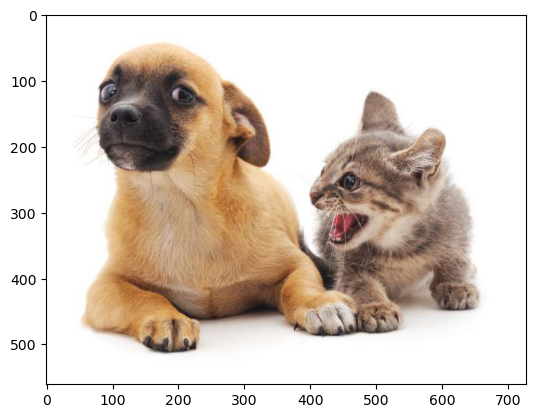

In [ ]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt

img = plt.imread('../img/catdog.jpg')
h, w = img.shape[:2]
fig, axes = plt.subplots(1, 1)
axes.imshow(img)

回想一下，在 :numref:`sec_conv_layer`中，我们将卷积图层的二维数组输出称为特征图。
通过定义特征图的形状，我们可以确定任何图像上均匀采样锚框的中心。

`display_anchors`函数定义如下。
我们[**在特征图（`fmap`）上生成锚框（`anchors`），每个单位（像素）作为锚框的中心**]。
由于锚框中的$(x, y)$轴坐标值（`anchors`）已经被除以特征图（`fmap`）的宽度和高度，因此这些值介于0和1之间，表示特征图中锚框的相对位置。

由于锚框（`anchors`）的中心分布于特征图（`fmap`）上的所有单位，因此这些中心必须根据其相对空间位置在任何输入图像上*均匀*分布。
更具体地说，给定特征图的宽度和高度`fmap_w`和`fmap_h`，以下函数将*均匀地*对任何输入图像中`fmap_h`行和`fmap_w`列中的像素进行采样。
以这些均匀采样的像素为中心，将会生成大小为`s`（假设列表`s`的长度为1）且宽高比（`ratios`）不同的锚框。


In [3]:
# sizes:缩放比例列表
# ratios:宽高比列表
def anchor_generator(picture, sizes, ratios):
    """生成以每个像素为中心具有不同形状的锚框"""
    # picture(B,C,H,W)
    device, num_sizes, num_ratios = picture.device, len(sizes), len(ratios)
    # size_tensor：不同缩放比例的个数
    size_tensor = torch.tensor(sizes, device=device)
    # ratio_tensor：不同宽高比的个数
    ratio_tensor = torch.tensor(ratios, device=device)


    # 一、像素坐标系：物理坐标系
    # .----->x
    # |
    # y
    # picture_h:y轴方向上的像素数
    # picture_w:x轴方向上的像素数
    picture_h, picture_w = picture.shape[-2:]   
    # 为了将锚点移动到像素的中心，需要设置偏移量。
    # 因为一个像素的高为1且宽为1，我们选择偏移我们的中心0.5
    offset_h, offset_w = 0.5, 0.5 # 单位：像素

    # 二、锚框坐标系：逻辑坐标系（归一化坐标）(定位坐标)
    # .----->1
    # |
    # 1
    # 给像素坐标系覆上锚框坐标系


    # 定锚框中心物理坐标
    center_y = (torch.arange(picture_h, device=device) + offset_h) # 锚框中心的y坐标
    center_x = (torch.arange(picture_w, device=device) + offset_w) # 锚框中心的x坐标
    # 归一化锚框中心物理坐标到逻辑坐标
    center_y_logical = center_y / picture_h # 锚框中心的y坐标归一化到[0,1]
    center_x_logical = center_x / picture_w # 锚框中心的x坐标归一化到[0,1]

    # 组合所有中心点的逻辑坐标
    shift_y, shift_x = torch.meshgrid(center_y_logical, center_x_logical, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # 第一步：[[x,y,x,y]]:(h*w,4)
    # 第二步：独立复制第0维度:(bpp*h*w,4)
    # bbox_center_logic_grid(bpp*h*w, 4)是用来生成锚框的中心逻辑坐标(原材料)
    # 这里为什么使用了两组中心坐标：因为后面需要算左上和右下的坐标，需要两组中心坐标来计算
    bbox_center_logic_grid = torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1).repeat_interleave((num_sizes + num_ratios - 1), dim=0)

    # ---------------------------------------------------------------------------- # 

    # 根据size和ratio计算锚框的实际物理长度
    # w(bpp,)=(n+m-1,)
    # (s0,r0),(s1,r0),(s3,r0),...,(sn-1,r0):n
    # (s0,r1),(s0,r2),(s0,r3),...,(s0,rm-1):m-1
    bbox_w = torch.cat((
        size_tensor * torch.sqrt(ratio_tensor[0]),
        sizes[0] * torch.sqrt(ratio_tensor[1:])
    )) * picture_h
    # h(bpp,)=(n+m-1,)
    bbox_h = torch.cat((
        size_tensor / torch.sqrt(ratio_tensor[0]),
        sizes[0] / torch.sqrt(ratio_tensor[1:])
    )) * picture_h

    # 归一化，得到锚框的归一化长度
    bbox_w_logic = bbox_w / picture_w
    bbox_h_logic = bbox_h / picture_h

    # 取半，得到锚框的归一化半长
    bbox_w_half_logic = bbox_w_logic / 2 # len(bbox_w_half_logic)=n+m-1
    bbox_h_half_logic = bbox_h_logic / 2 # len(bbox_h_half_logic)=n+m-1


    # bbox_w_h_half_logic(bpp*h*w, 4)
    # 第一步：[[-w,-h,w,h]]:(n+m-1,4)
    # 第二步：整体复制in_height * in_width次，得到(bpp*h*w,4)
    bbox_w_h_half_logic = torch.stack([-bbox_w_half_logic, -bbox_h_half_logic, bbox_w_half_logic, bbox_h_half_logic], dim=1).repeat(picture_h * picture_w, 1)


    # 中心坐标+长宽偏移量=左上角坐标、右下角坐标
    # bbox_center_logic_grid            (bpp*h*w, 4)
    # bbox_w_h_half_logic               (bpp*h*w, 4)
    # bbox_logic                        (bpp*h*w, 4)
    # (左上角x, 左上角y, 右下角x, 右下角y)
    bbox_logic = bbox_center_logic_grid + bbox_w_h_half_logic
    # 输出：(1, bpp*h*w, 4)
    return bbox_logic.unsqueeze(0)

In [11]:
import matplotlib.pyplot as plt
# 显示边界框bbox/锚框anchor
# boxes:盒子的实际坐标，格式为(左上x,左上y,右下x,右下y)
def show_boxes(axes, boxes, labels=None, colors=None):
    """显示某个像素为中心的所有边界框"""
    # 安全检查
    def _make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = _make_list(obj=labels, default_values=[])
    colors = _make_list(obj=colors, default_values=['b', 'g', 'r', 'm', 'c'])
    
    # 遍历所有边界框
    for i, box in enumerate(boxes):
        color = colors[i % len(colors)] # 循环使用颜色列表
        # 创建矩形数据，还没有添加到绘图区(axes)中
        rect = plt.Rectangle(xy=(box[0], box[1]), width=box[2]-box[0], height=box[3]-box[1],fill=False, edgecolor=color, linewidth=2)
        axes.add_patch(rect) # 把矩形数据添加到绘图区(axes)中
        # 每个边界框上添加标签文本
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w' # 文本颜色，与边界框颜色相反
            bounding_box  = {'facecolor': color, 'lw': 0} # 文本背景框设置，使用与边界框相同的颜色
           
            axes.text(rect.xy[0],          # 文本左下角在图中的横坐标（锚点为左下角）
                      rect.xy[1],          # 文本左下角在图中的纵坐标
                      labels[i],           # 要显示的文本内容（当前边界框对应的标签）
                      va='center',         # 垂直对齐方式：居中
                      ha='center',         # 水平对齐方式：居中
                      fontsize=9,          # 字体大小
                      color=text_color,    # 字体颜色（与边界框颜色形成对比）
                      bbox=bounding_box)   # 文本背景框样式字典


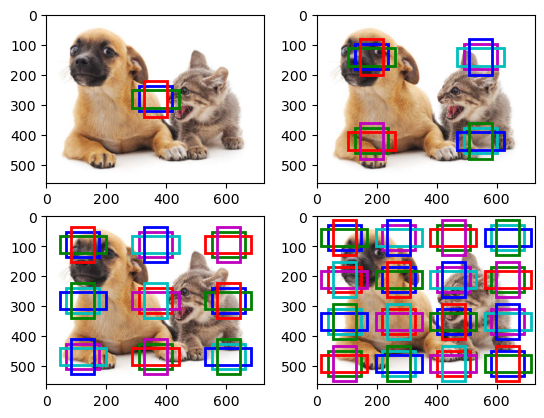

In [21]:
import torch
import matplotlib.pyplot as plt


# 通过特征图生成锚框(内部还是调用generate_anchors)
def generate_anchors_by_feature_map(fmap_w, fmap_h, scales, ratios=[1, 2, 0.5]):
    # 前两个维度上的值不影响输出
    # 等效特征图(B, C, h, w)
    fmap = torch.zeros((1, 3, fmap_h, fmap_w)) # 影子张量
    # 在特征图上生成锚框:归一化坐标
    anchors = anchor_generator(fmap, scales, ratios)
    # 输出：(1, bpp*h*w, 4)
    return anchors

img = plt.imread('../img/catdog.jpg')
h, w = img.shape[:2]
fig, axes = plt.subplots(2, 2)

# 第一个特征图(1x1)
axes[0, 0].imshow(img)
anchors = generate_anchors_by_feature_map(fmap_w=1, fmap_h=1, scales=[0.15])
box_scale = torch.tensor((w, h, w, h))
show_boxes(axes[0, 0], anchors[0] * box_scale)

# 第二个特征图(2x2)
axes[0, 1].imshow(img)
anchors = generate_anchors_by_feature_map(fmap_w=2, fmap_h=2, scales=[0.15])
box_scale = torch.tensor((w, h, w, h))
show_boxes(axes[0, 1], anchors[0] * box_scale)

# 第三个特征图(3x3)
axes[1, 0].imshow(img)
anchors = generate_anchors_by_feature_map(fmap_w=3, fmap_h=3, scales=[0.15])
box_scale = torch.tensor((w, h, w, h))
show_boxes(axes[1, 0], anchors[0] * box_scale)

# 第四个特征图(4x4)
axes[1, 1].imshow(img)
anchors = generate_anchors_by_feature_map(fmap_w=4, fmap_h=4, scales=[0.15])
box_scale = torch.tensor((w, h, w, h))
show_boxes(axes[1, 1], anchors[0] * box_scale)


plt.show()

原本c个通道的数据 → 可以被转换成一个“头”（head），输出a个锚框的类别+偏移量。  
这就是所谓的“检测头”（Detection Head）—— 把特征图转化为检测结果。  
“本质上，我们用输入图像在某个感受野区域内的信息，来预测输入图像上与该区域位置相近的锚框类别和偏移量。”

## 多尺度检测

既然我们已经生成了多尺度的锚框，我们就将使用它们来检测不同尺度下各种大小的目标。
下面，我们介绍一种基于CNN的多尺度目标检测方法，将在 :numref:`sec_ssd`中实现。

在某种规模上，假设我们有$c$张形状为$h \times w$的特征图。
使用 :numref:`subsec_multiscale-anchor-boxes`中的方法，我们生成了$hw$组锚框，其中每组都有$a$个中心相同的锚框。
例如，在 :numref:`subsec_multiscale-anchor-boxes`实验的第一个尺度上，给定10个（通道数量）$4 \times 4$的特征图，我们生成了16组锚框，每组包含3个中心相同的锚框。
接下来，每个锚框都根据真实值边界框来标记了类和偏移量。
在当前尺度下，目标检测模型需要预测输入图像上$hw$组锚框类别和偏移量，其中不同组锚框具有不同的中心。


假设此处的$c$张特征图是CNN基于输入图像的正向传播算法获得的中间输出。
既然每张特征图上都有$hw$个不同的空间位置，那么相同空间位置可以看作含有$c$个单元。
根据 :numref:`sec_conv_layer`中对感受野的定义，特征图在相同空间位置的$c$个单元在输入图像上的感受野相同：
它们表征了同一感受野内的输入图像信息。
因此，我们可以将特征图在同一空间位置的$c$个单元变换为使用此空间位置生成的$a$个锚框类别和偏移量。
本质上，我们用输入图像在某个感受野区域内的信息，来预测输入图像上与该区域位置相近的锚框类别和偏移量。

当不同层的特征图在输入图像上分别拥有不同大小的感受野时，它们可以用于检测不同大小的目标。
例如，我们可以设计一个神经网络，其中靠近输出层的特征图单元具有更宽的感受野，这样它们就可以从输入图像中检测到较大的目标。

简言之，我们可以利用深层神经网络在多个层次上对图像进行分层表示，从而实现多尺度目标检测。
在 :numref:`sec_ssd`，我们将通过一个具体的例子来说明它是如何工作的。

## 小结

* 在多个尺度下，我们可以生成不同尺寸的锚框来检测不同尺寸的目标。
* 通过定义特征图的形状，我们可以决定任何图像上均匀采样的锚框的中心。
* 我们使用输入图像在某个感受野区域内的信息，来预测输入图像上与该区域位置相近的锚框类别和偏移量。
* 我们可以通过深入学习，在多个层次上的图像分层表示进行多尺度目标检测。

## 练习

1. 根据我们在 :numref:`sec_alexnet`中的讨论，深度神经网络学习图像特征级别抽象层次，随网络深度的增加而升级。在多尺度目标检测中，不同尺度的特征映射是否对应于不同的抽象层次？为什么？
1. 在 :numref:`subsec_multiscale-anchor-boxes`中的实验里的第一个尺度（`fmap_w=4, fmap_h=4`）下，生成可能重叠的均匀分布的锚框。
1. 给定形状为$1 \times c \times h \times w$的特征图变量，其中$c$、$h$和$w$分别是特征图的通道数、高度和宽度。怎样才能将这个变量转换为锚框类别和偏移量？输出的形状是什么？


[Discussions](https://discuss.d2l.ai/t/2948)
